# Ch 7. 模擬障礙物對緊急疏散效率的影響

在醫院或大型公共建築中，緊急事故（如火災、地震、煙霧外洩）發生時，如何有效率地疏散人群是重要課題。過去研究指出：在出口附近適度設置障礙物（如柱子、屏障）反而能減少瓶頸現象、提升疏散效率。本作業會使用粒子模型模擬人群疏散行為，並探討在不同障礙物配置、不同人群參數下，對疏散效率（完成疏散所需時間）的影響

1. 使用粒子模型模擬人群疏散情境
2. 比較不同參數（人數、速度、障礙物形狀與位置）對疏散效率的影響
3. 找出最佳的障礙物設置方案，並提供合理解釋
4. 完成一份具備資料、圖表與分析的報告

## Section 1. Data Ingestion & Geometry Definition

在進行連續空間模擬之前，首先需要先定義狀態空間 $\Omega$。其中疏散區域定義為一個二維歐幾里得子空間 $\Omega \subset \mathbb{R}^2$，空間的邊界由題目給定的 $x_{size}$ 與 $y_{exit}$ 決定。雖然物理模擬主要依賴連續座標，但首先要載入題目提供的資料集，來檢視資料集的拓樸結構是否能對應到需求的的幾何邊界，或者僅作為路徑規劃的圖

In [1]:
import pandas as pd
df_links = pd.read_csv('ch7_links.csv')
print(df_links.head())

  Unnamed: 0  Node0  Node1  Node2  Node3  Node4  Node5  Node6  Node7  Node8  \
0      Node0    0.0    0.0    0.0    0.0    0.0    1.0    0.0    0.0    0.0   
1      Node1    0.0    0.0    0.0    0.0    0.0    1.0    0.0    0.0    0.0   
2      Node2    0.0    0.0    0.0    0.0    1.0    1.0    1.0    0.0    0.0   
3      Node3    0.0    0.0    0.0    0.0    0.0    0.0    0.0    1.0    0.0   
4      Node4    0.0    0.0    1.0    0.0    0.0    0.0    0.0    1.0    1.0   

   ...  Node10  Node11  Node12  Node13  Node14  Node15  Node16  Node17  \
0  ...     0.0     0.0     0.0     0.0     0.0     1.0     0.0     0.0   
1  ...     0.0     1.0     0.0     1.0     0.0     0.0     1.0     0.0   
2  ...     1.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3  ...     0.0     0.0     0.0     0.0     0.0     1.0     0.0     0.0   
4  ...     1.0     0.0     0.0     0.0     0.0     1.0     0.0     0.0   

   Node18  Node19  
0     0.0     0.0  
1     0.0     0.0  
2     0.0     0.0  


In [2]:
df_route = pd.read_csv('ch7_route.csv')
print(df_route)

   1  1.1  1.2  1.3  0  0.1  1.4  1.5  1.6  1.7
0  1    1    1    1  0    0    1    1    1    1
1  1    1    1    1  1    1    1    1    1    1
2  1    1    1    1  1    1    1    1    1    1
3  1    1    1    1  1    1    1    1    1    1
4  1    1    1    1  1    1    1    1    1    1
5  0    0    0    0  0    0    1    1    1    1
6  0    0    0    0  0    0    1    1    1    1
7  0    0    0    0  0    0    1    1    1    1
8  0    0    0    0  0    0    1    1    1    1


## Section 2. Begin Simulation

### Step A. Social Force Model

首先檢視輸入資料的數學屬性。回顧電腦科學早期發展（如 1959 年 Dijkstra 或 1968 年 Hart 等人的 A* 演算法），人群移動常被建模為圖論問題。在數學上通常定義 Metric Graph $G = (V, E)$，其中狀態 $s$ 為離散節點 $s \in V$，狀態轉移則是瞬時或基於權重的跳躍 $s_t \to s_{t+1}$

原始論文：[Helbing, D., & Molnár, P. (1995). Social force model for pedestrian dynamics. *Physical Review E*, *51*(5), 4282–4286. https://doi.org/10.1103/PhysRevE.51.4282](https://doi.org/10.1103/PhysRevE.51.4282)

對應到這次作業的資料：

* **Adjacency Matrix ($A$)**：`df_links` 構成圖 $G$ 的鄰接矩陣（$|V|=20$），這適用於狀態空間有限的離散路徑規劃。
* **Occupancy Grid ($M$)**：`df_route` 呈現為 $9 \times 10$ 的二元矩陣 $M_{ij} \in \{0, 1\}$。觀察資料分佈可見左下角（Row 5-8, Col 0-3）存在明顯的 `0` 值區塊，這在網格地圖中代表障礙物或非行走區域。

然而，這類離散模型難以描述 **擁擠**、**推擠** 或 **慣性**，因為圖論中的節點 $v$ 通常缺乏「容量」限制，亦不具備模擬物理碰撞的條件。

Helbing & Molnár (1995) 提出的 Social Force Model（SFM）屬於基於牛頓力學的 **微觀動力系統**，將行人視為在連續的 Euclidean Space 中的 **自驅動粒子**，具有以下特性

1.  **連續相空間**：粒子狀態定義於 $(\mathbf{x}, \mathbf{v}) \in \mathbb{R}^4$，需要操作位勢場的梯度 $\nabla U(\mathbf{x})$。
2.  **模擬區域定義**：引入牛頓運動定律來描述行為，定義模擬區域 $\Omega$ 與邊界 $\partial \Omega$ 為：

    $$
    \Omega = \{ (x, y) \in \mathbb{R}^2 \mid 0 \le x \le x_{max}, 0 \le y \le y_{max} \}
    $$

    $$
    \partial \Omega = \{ (x, y) \in \mathbb{R}^2 \mid x = 0 \text{ or } x = x_{max} \text{ or } y = 0 \text{ or } y = y_{max} \}
    $$

因為本次作業重點在於 $\Omega \subset \mathbb{R}^2$ 的連續空間操作，粒子的位置向量 $\mathbf{x} \in \mathbb{R}^2$ 與速度向量 $\mathbf{v} \in \mathbb{R}^2$ 必須保持連續且可微分，以嚴格滿足牛頓運動定律。

因此，為了精確符合規範中的幾何要求（如 $x_{size}=8, y_{exit}=6$），就會建議直接操作 **解析幾何 (Analytical Geometry)** 的方式直接定義邊界條件，而非將離散網格 $M$ 強制拉伸進行映射（不然只有四方向或八方向）。這樣就可以在確保物理引擎的數值精度同時，也不會因為制約於網格解析度而降低

### Step B Geometry Definition

將模擬區域 $\Omega$ 定義為二維笛卡兒座標系中的一個閉區間：

$$
\Omega = [0, X_{SIZE}] \times [0, Y_{SIZE}] \subset \mathbb{R}^2
$$

定義模擬區域 $\Omega$ 為連續空間，範圍 $x \in [0, X_{SIZE}], y \in [0, Y_{SIZE}]$。為了模擬人流由左向右穿越瓶頸（Bottleneck）的行為，給定範例程式碼中，在 $x = X_{MID}$ 處建立一道垂直隔間，定義如下

- **Partition Location**: $x_p = X_{SIZE} / 2$
- **Door Center**: $\vec{r}_{door} = (x_p, Y_{SIZE} / 2)$
- **Door Width**: $w_{door} = 1.2$

In [3]:
X_SIZE = 8.0
Y_SIZE = 6.0

X_PARTITION = X_SIZE / 2.0  # 4.0
DOOR_WIDTH = 1.0            # Gap from y=0 to y=1
EXIT_TARGET = (X_PARTITION, DOOR_WIDTH / 2.0) # (4.0, 0.5)

WALL_THICKNESS = 0.2

在這個區域的邊界 $\partial \Omega$ 與內部空間中，施加了兩種物理條件：

1.  **Reflecting / Repulsive Boundary** 即「牆壁」，粒子無法穿越且會受到斥力。範圍包含四周的 **系統邊界** 以及 **內部的隔牆**
2.  **Absorbing Boundary** 即「出口」，粒子到達此處視為離開系統（或進入下一個區域）。位於隔牆底部的缺口處，即 $x=X_{PARTITION}, y \in [0, w_{door}]$

為了在物理引擎中實作這些條件，就會需要定義牆壁集合 $S_{wall}$ 為一組矩形障礙物。其中邊界由以下五個部分組成：

1.  **Outer Walls**: 完全封閉的四周邊界，包含 Top ($y=Y_{SIZE}$)、Bottom ($y=0$)、Left ($x=0$) 與 Right ($x=X_{SIZE}$)
2.  **Partition Wall**: 位於 $x=X_{PARTITION}$ 的垂直隔板。為了形成底部出口，此牆壁封鎖了 $y > w_{door}$ 的區域，即從 $y=w_{door}$ 延伸至 $y=Y_{SIZE}$

In [4]:
walls_geom = [
    # 1. Outer Boundaries
    (0 - WALL_THICKNESS, Y_SIZE, X_SIZE + 2*WALL_THICKNESS, WALL_THICKNESS),          # Top
    (0 - WALL_THICKNESS, -WALL_THICKNESS, X_SIZE + 2*WALL_THICKNESS, WALL_THICKNESS), # Bottom
    (-WALL_THICKNESS, 0, WALL_THICKNESS, Y_SIZE),                                     # Left
    (X_SIZE, 0, WALL_THICKNESS, Y_SIZE),                                              # Right
    
    # 2. Partition Wall (Blocking y > 1.0), Starts at y=1.0, extends to y=6.0 (Height = 5.0)
    (X_PARTITION - WALL_THICKNESS/2, DOOR_WIDTH, WALL_THICKNESS, Y_SIZE - DOOR_WIDTH)
]

在視覺化方面，可以使用 `matplotlib` 來繪製模擬區域 $\Omega$。其中圖中黑色區塊對應上述定義的實體牆壁，紅色叉號與綠色標記則指出粒子應前往的目標位置（Target Exit），即隔牆底部的連通口。這可以透過 `matplotlib.patches.Rectangle` 畫出具有厚度 $\delta_{wall}$ 的剛性邊界，並標記出口目標點

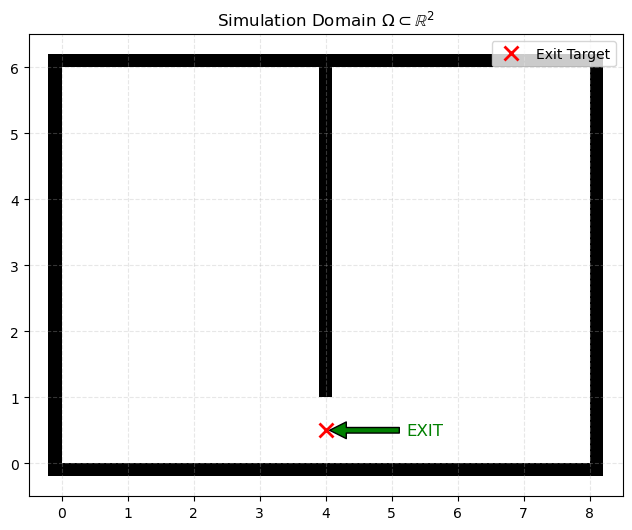

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 6))

# Step A.1
ax.set_xlim(-0.5, X_SIZE + 0.5)
ax.set_ylim(-0.5, Y_SIZE + 0.5)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_title(r"Simulation Domain $\Omega \subset \mathbb{R}^2$")

# Step A.2
for w in walls_geom:
    ax.add_patch(patches.Rectangle((w[0], w[1]), w[2], w[3], facecolor='k'))

# Mark Exit Target
ax.plot(*EXIT_TARGET, 'rx', markersize=10, markeredgewidth=2, label='Exit Target')

# Annotate Flow
ax.annotate('EXIT', xy=EXIT_TARGET, xytext=(X_PARTITION + 1.5, 0.5),
            arrowprops=dict(facecolor='green', shrink=0.05),
            ha='center', va='center', fontsize=12, color='green')

plt.legend()
plt.show()

### Step C. SFM Physics Engine Kernel in Vector Fields: Goal and Social Forces

在 $\Omega$ 的左半部子集 $\Omega_{init}$ 中生成 $N$ 個粒子，誕生成的粒子分佈並非單純的均勻分佈，因為物理實體之間具有不可重疊的體積屬性。在數學上被建模為 **Hard-Core Point Process**，其有效 Configuration Space 主要受限於兩個幾何約束：

1. **動態互斥**：任意兩粒子 $i, j$ 之間的距離必須大於直徑，即 $\|\mathbf{x}_i - \mathbf{x}_j\|_2 \ge 2r$
2. **靜態互斥**：粒子不可生成於障礙物（圓柱或牆體）內部。對於障礙物集合 $\mathcal{O}$ 中的任意物件 $o$，需滿足 $\text{dist}(\mathbf{x}_i, o) \ge r$

為了滿足上述條件，採用 **Rejection Sampling** 演算法進行座標生成：

1. **Sampling**：從均勻分佈 $\mathbf{x}_{cand} \sim U(\Omega_{init})$ 中抽取候選座標。其中 $\Omega_{init} = [0.5, X_{partition}-0.5] \times [0.5, Y_{max}-0.5]$
2. **Constraint A (Static)**：檢查 $\mathbf{x}_{cand}$ 是否與任一障礙物重疊。對於圓形障礙物，檢查圓心距離是否小於兩者半徑和；對於矩形障礙物，檢查座標是否落入擴張半徑 $r$ 後的矩形範圍內。若重疊則拒絕（Reject）
3. **Constraint B (Dynamic)**：計算 $\mathbf{x}_{cand}$ 與已生成粒子集合 $S_{curr}$ 的最小距離 $d_{min} = \min_{\mathbf{p} \in S_{curr}} \|\mathbf{x}_{cand} - \mathbf{p}\|$. 若 $d_{min} < 2r$ 則拒絕

僅當上述兩條件皆通過時，將 $\mathbf{x}_{cand}$ 加入集合 $S$，直至粒子數達到 $N$

In [6]:
def init_simulation(num_agents, x_size, y_size, radius, obstacles, seed=42):

    np.random.seed(seed)    
    pos = np.zeros((num_agents, 2))
    vel = np.zeros((num_agents, 2))
    
    count = 0
    max_attempts = 50000
    attempts = 0
    
    # Define spawn region (Left Room only)
    x_spawn_max = 4.0 # x_partition
    
    while count < num_agents and attempts < max_attempts:
        attempts += 1
        
        # 1. Sample uniformly in the left room
        # Padding 0.5 to avoid spawning exactly on outer walls
        x_cand = np.random.uniform(0.5, x_spawn_max - 0.5)
        y_cand = np.random.uniform(0.5, y_size - 0.5)
        candidate = np.array([x_cand, y_cand])
        
        # 2. Constraint A: Check Obstacle Collision (NEW)
        if _check_obstacle_collision(candidate, obstacles, radius):
            continue # Reject
            
        # 3. Constraint B: Check Agent-Agent Collision (Existing)
        if count > 0:
            existing_agents = pos[:count]
            dists = np.linalg.norm(existing_agents - candidate, axis=1)
            if np.min(dists) < 2 * radius:
                continue # Reject
        
        # Accept
        pos[count] = candidate
        count += 1
    
    if count < num_agents:
        print(f"Warning: Only placed {count}/{num_agents} agents after {max_attempts} attempts.")
        
    return pos, vel

In [7]:
def _check_obstacle_collision(candidate, obstacles, agent_radius):
    cx, cy = candidate
    
    for obs in obstacles:
        if obs['type'] == 'circle':
            ox, oy = obs['center']
            r_obs = obs['radius']
            # Distance check: dist < r_agent + r_obs
            dist_sq = (cx - ox)**2 + (cy - oy)**2
            min_dist = agent_radius + r_obs
            if dist_sq < min_dist**2:
                return True
                
        elif obs['type'] == 'rect':
            x_min, x_max = obs['x_range']
            y_min, y_max = obs['y_range']
            if (x_min - agent_radius < cx < x_max + agent_radius) and (y_min - agent_radius < cy < y_max + agent_radius):
                return True
                
    return False

每個粒子 $i$ 受到的合力 $\mathbf{F}_i$ 是三個向量場的疊加：

$$
\mathbf{F}_i = \mathbf{F}_{goal} + \mathbf{F}_{social} + \mathbf{F}_{obs}
$$

#### Module 2: Goal Force $\mathbf{F}_{goal}$

粒子希望以期望速度 $v_d$ 沿著方向 $\mathbf{e}_i^0$ 移動，在雙房間場景中，目標位置 $\mathbf{x}_{exit}$ 設定為隔牆底部的連通口中心

驅動力 $\mathbf{F}_{goal}$ 會模擬粒子調整實際速度 $\mathbf{v}_i$ 以逼近期望速度 $v_d$ 的過程

$$\mathbf{F}_{goal, i} = \frac{v_d \mathbf{e}_i^0 - \mathbf{v}_i}{\tau}$$

其中 $\tau$ 是弛豫時間（Relaxation Time），$\mathbf{e}_i^0$ 是指向出口的單位向量

$$\mathbf{e}_i^0 = \frac{\mathbf{x}_{exit} - \mathbf{x}_i}{\|\mathbf{x}_{exit} - \mathbf{x}_i\|}$$

In [8]:
def compute_goal_force(pos, vel, params):
    
    x_part = params['x_partition']

    target_door = np.array([x_part + 0.5, 0.5])     
    target_exit = np.array([params['x_size'], 0.5]) # Target for right-room agents
    
    # Vectorized target assignment
    goals = np.zeros_like(pos)
    mask_left = pos[:, 0] < x_part
    
    goals[mask_left] = target_door
    goals[~mask_left] = target_exit
    
    diff = goals - pos
    dist = np.linalg.norm(diff, axis=1, keepdims=True)
    e_goal = diff / (dist + 1e-6)
    
    return (params['v_desired'] * e_goal - vel) / params['tau']

#### Module 3: Social Force $\mathbf{F}_{social}$

這是基於距離的指數斥力場

$$
\mathbf{F}_{ij} = A \cdot \exp\left(\frac{2r - d_{ij}}{B}\right) \cdot \mathbf{n}_{ij}, \quad \mathbf{n}_{ij} = \frac{\mathbf{x}_i - \mathbf{x}_j}{d_{ij}}
$$

其中 $\mathbf{n}_{ij}$ 是由 $j$ 指向 $i$ 的斥力方向

但因為這屬於成對交互作用，在計算這種力的時候，需要考慮所有成對的斥力。因此

$$
\forall (i, j), \quad \mathbf{F}_{social, i} = \sum_{j \neq i} A_p \exp\left(\frac{r_{ij} - d_{ij}}{B_p}\right) \mathbf{n}_{ij}
$$

In [9]:
def compute_social_force(pos, params):

    N = pos.shape[0]
    forces = np.zeros((N, 2))
    
    radius = params['radius']
    A_p = params['A_p']
    B_p = params['B_p']
    
    # Pairwise computation
    for i in range(N):
        for j in range(i + 1, N):
            delta = pos[i] - pos[j]
            d_ij = np.linalg.norm(delta)
            n_ij = delta / (d_ij + 1e-6)
            
            # Repulsion strength: r_ij = 2 * radius
            val = A_p * np.exp((2 * radius - d_ij) / B_p)
            f_vec = val * n_ij
            
            # Action-Reaction
            forces[i] += f_vec
            forces[j] -= f_vec
            
    return forces

### Step E. SFM Physics Engine Kernel in Vector Fields: All Static Obstacles

定義集合 $W$ 為所有靜態物體的集合：

- $W_{boundaries}$ 用來模擬區域的四面牆做為邊界
- $W_{internal}$ 是人工放置的圓形或矩形障礙物

根據疊加原理，環境總斥力 $\mathbf{F}_{obs}$ (或程式碼中的 `f_wall_total`) 是所有 $w \in W$ 產生的斥力總和：

$$
\mathbf{F}_{obs} = \sum_{w \in W} \mathbf{F}_{iw} = \underbrace{\sum_{b \in W_{boundaries}} \mathbf{F}_{ib}}_{\text{f\_boundaries}} + \underbrace{\sum_{o \in W_{internal}} \mathbf{F}_{io}}_{\text{f\_obstacles}}
$$

所以這邊就需要拆開處理：

1. 數學上，若將每個障礙物 $w \in W$ 視為一個產生排斥位勢場 $U_w(\mathbf{x})$ 的源。粒子 $i$ 在位置 $\mathbf{x}_i$ 受到該場的作用力 $\mathbf{F}_{iw}$ 定義為該位勢的負梯度：

    $$
    \mathbf{F}_{iw}(\mathbf{x}_i) = - \nabla U_w(\mathbf{x}_i)
    $$

2. 首先，定義粒子 $i$ 到障礙物 $w$（視為幾何集合 $\Omega_w$）的歐幾里得最短距離函數 $D_w(\mathbf{x})$：

    $$
    D_w(\mathbf{x}) = \min_{\mathbf{p} \in \Omega_w} \| \mathbf{x} - \mathbf{p} \|
    $$

    該函數的梯度 $\nabla D_w(\mathbf{x})$ 具有幾何意義：它是一個單位向量，指向遠離障礙物表面最近點的方向。我們記作 $\mathbf{n}_{iw}$（Normal Vector）

3. 在 Helbing (1995) 的模型中，就假設該位勢場隨著距離呈現指數衰減，模擬生物體對於「接近物體」的心理壓力。換句話說，人與人距離越接近時，心理壓力程度就會急劇上升。若考慮粒子半徑 $r_i$，則位勢函數定義為：

    $$
    U_w(D_w) = A_w B_w \exp\left(\frac{r_i - D_w}{B_w}\right)
    $$

4. 其中 $A_w$ 是強度常數，$B_w$ 是作用範圍常數。這時候根據連鎖律，可以對位置 $\mathbf{x}$ 進行微分：

    $$
    \begin{aligned}
    \mathbf{F}_{iw} &= - \nabla U_w(D_w(\mathbf{x})) \\
    &= - \frac{d U_w}{d D_w} \cdot \nabla D_w(\mathbf{x}) \\
    &= - \left[ A_w B_w \cdot \left(-\frac{1}{B_w}\right) \exp\left(\frac{r_i - D_w}{B_w}\right) \right] \cdot \mathbf{n}_{iw} \\
    &= A_w \exp\left(\frac{r_i - D_w}{B_w}\right) \mathbf{n}_{iw}
    \end{aligned}
    $$

5. 由於力是向量，且位勢是純量。總位勢場是所有獨立障礙物位勢的線性疊加

    $$
    U_{total}(\mathbf{x}) = \sum_{w \in W} U_w(\mathbf{x})
    $$

    因此，總障礙物斥力即為各分力的向量和為

    $$
    \mathbf{F}_{wall, i} = \sum_{w \in W} \mathbf{F}_{iw} = \sum_{w \in W} A_w \exp\left(\frac{r_i - d_{iw}}{B_w}\right) \mathbf{n}_{iw}
    $$

但這樣操作在程式上非常不方便，那既然總位勢場是累加的

$$
U_{total} = U_{boundaries} + \sum U_{obstacles}
$$

那有關力的計算也可以完全解耦

$$
\mathbf{F}_{wall, total} = \mathbf{F}_{boundaries} + \mathbf{F}_{obstacles}
$$

因此就可以得到兩個模組，分別為 Canvas Boundaries 與 Internal Obstacles

#### Module 4: All Static Boundaries $\mathbf{F}_{boundaries}$

這部分處理 $\Omega$ 的幾何限制。根據目前的雙房間設定，靜態邊界包含兩個部分：

1.  **Outer Boundaries** 即系統的四周外框，法向量 $\mathbf{n}$ 為常數，如 $(1,0), (0,1)$ 等
2.  **Partition Wall** 即位於 $x=X_{PARTITION}$ 的垂直隔板，可以視為一條線段 $L_{partition}$，粒子受到的斥力基於「點到線段的最短距離」

為了保持計算效率，外框使用平面投影公式計算，而隔牆則使用通用的線段投影演算法

In [10]:
def _get_segment_force(p, seg_start, seg_end, params):

    radius, A_w, B_w = params['radius'], params['A_w'], params['B_w']
    
    # 1. Vector Projection to find closest point
    seg_vec = seg_end - seg_start
    p_vec = p - seg_start
    
    seg_len_sq = np.dot(seg_vec, seg_vec)
    if seg_len_sq == 0: return np.zeros(2)
    
    t = np.dot(p_vec, seg_vec) / seg_len_sq
    t_clamped = np.clip(t, 0.0, 1.0)
    
    closest = seg_start + t_clamped * seg_vec
    
    # 2. Compute Distance & Normal
    delta = p - closest
    dist = np.linalg.norm(delta)

    # Avoid singularity
    if dist == 0: return np.zeros(2)
    n = delta / dist
    
    # 3. Compute Exponential Repulsion
    return n * A_w * np.exp((radius - dist) / B_w)

def _compute_boundary_forces(pos, params):

    N = pos.shape[0]
    forces = np.zeros((N, 2))

    radius, A_w, B_w = params['radius'], params['A_w'], params['B_w']
    x_sz, y_sz = params['x_size'], params['y_size']

    # Partition Geometry: x=4.0, y from 1.0 to 6.0
    x_part = params['x_partition']
    door_w = params['door_width']
    
    part_start = np.array([x_part, door_w])
    part_end   = np.array([x_part, y_sz])

    for i in range(N):
        p = pos[i]
        f_i = np.zeros(2)
        
        # A. Outer Walls (Simple Plane Repulsion)
        f_i[0] += A_w * np.exp((radius - p[0]) / B_w)          # Left Wall (x=0)
        f_i[0] -= A_w * np.exp((radius - (x_sz - p[0])) / B_w) # Right Wall (x=X)
        f_i[1] += A_w * np.exp((radius - p[1]) / B_w)          # Bottom Wall (y=0)
        f_i[1] -= A_w * np.exp((radius - (y_sz - p[1])) / B_w) # Top Wall (y=Y)
        
        # B. Partition Wall (Segment Repulsion)
        f_i += _get_segment_force(p, part_start, part_end, params)
        forces[i] = f_i

    return forces

#### Module 5: All Internal Obstacles $\mathbf{F}_{obstacles}$

這部分處理圓形或矩形障礙物。對應到 _Step E.2_ 距離梯度計算 與 _Step E.3_ 的位勢定義

In [11]:
def _compute_obstacle_forces(pos, obstacles, params):
    N = pos.shape[0]
    forces = np.zeros((N, 2))
    
    if not obstacles:
        return forces

    radius = params['radius']
    A_w = params['A_w']
    B_w = params['B_w']
    k_push = 500.0  # Increase 'push_out_factor' to ensure agents inside obstacles are ejected

    for i in range(N):
        p = pos[i]
        f_i = np.zeros(2)
        
        for obs in obstacles:
            if obs['type'] == 'circle':
                c = np.array(obs['center'])
                r_obs = obs['radius']
                
                delta = p - c
                dist_center = np.linalg.norm(delta)
                
                # A. Outside the circle
                if dist_center > r_obs:
                    
                    n = delta / (dist_center + 1e-6) # Direction: Center -> Agent
                    d_surf = dist_center - r_obs     # Distance to surface
                    val = A_w * np.exp((radius - d_surf) / B_w)
                    f_i += val * n
                
                # B. Inside the circle (Overlap) -> Strong Repulsion
                else:
                    n = delta / (dist_center + 1e-6)
                    # Force proportional to penetration depth
                    penetration = r_obs - dist_center
                    f_i += k_push * penetration * n

            elif obs['type'] == 'rect':
                x_min, x_max = obs['x_range']
                y_min, y_max = obs['y_range']
                
                # Check if inside rectangle
                if x_min < p[0] < x_max and y_min < p[1] < y_max:
                    # B. Inside: Find nearest edge to push out
                    d_left = p[0] - x_min
                    d_right = x_max - p[0]
                    d_bottom = p[1] - y_min
                    d_top = y_max - p[1]
                    
                    min_dist = min(d_left, d_right, d_bottom, d_top)
                    
                    if min_dist == d_left:   f_i += np.array([k_push, 0])
                    if min_dist == d_left:    f_i += np.array([-k_push, 0])
                    elif min_dist == d_right: f_i += np.array([k_push, 0])
                    elif min_dist == d_bottom:f_i += np.array([0, -k_push])
                    elif min_dist == d_top:   f_i += np.array([0, k_push])
                    
                else:
                    # A. Outside: Standard SFM
                    cx = np.clip(p[0], x_min, x_max)
                    cy = np.clip(p[1], y_min, y_max)
                    closest = np.array([cx, cy])
                    
                    delta = p - closest
                    dist = np.linalg.norm(delta)
                    
                    if dist > 0:
                        n = delta / dist
                        val = A_w * np.exp((radius - dist) / B_w)
                        f_i += val * n
        
        forces[i] = f_i
        
    return forces

#### Module 6: Aggregator of Wall Force

最後的主函數只負責執行 _Step E.5_ 線性疊加

In [12]:
def compute_wall_force(pos, obstacles, params):
    f_boundaries = _compute_boundary_forces(pos, params) # 1. Simulation Box
    f_obstacles = _compute_obstacle_forces(pos, obstacles, params) # 2. Internal Objects
    # Step E.5 Linear Superposition
    return f_boundaries + f_obstacles

### Step F. Force Aggregator

最後，前述提到每個粒子 $i$ 受到的合力 $\mathbf{F}_i$ 是三個向量場的疊加：

$$
\mathbf{F}_i = \mathbf{F}_{goal} + \mathbf{F}_{social} + \mathbf{F}_{obs}
$$

因此主迴圈只需要呼叫一個聚合函數，將這些分量向量相加

In [13]:
def compute_total_forces(pos, vel, obstacles, params):

    f_goal = compute_goal_force(pos, vel, params)
    f_social = compute_social_force(pos, params)
    f_wall = compute_wall_force(pos, obstacles, params)
    
    return f_goal + f_social + f_wall

### Step G. Numerical Integration: State Space Reduction


物理上，粒子的運動由牛頓第二定律描述：

$$
m \frac{d^2\mathbf{x}}{dt^2} = \mathbf{F}(\mathbf{x}, \mathbf{v}, t)
$$

這是一個二階線性 ODE，因為出現了對時間的兩次微分。但是為了進行數值積分（如 Euler Method），在操作上可以引入新的狀態變數 $\mathbf{v} = \frac{d\mathbf{x}}{dt}$，將上述的一個二階方程改寫為 **兩個耦合的一階線性 ODEs**：

1.  **Kinematics：**

    $$
    \frac{d\mathbf{x}}{dt} = \mathbf{v}
    $$

2.  **Dynamics：**
    
    $$
    \frac{d\mathbf{v}}{dt} = \frac{\mathbf{F}(\mathbf{x}, \mathbf{v})}{m} = \mathbf{a} 
    $$

這兩項就可以改寫成向量形式的狀態方程 $\dot{\mathbf{S}} = f(\mathbf{S})$，其中 $\mathbf{S} = [\mathbf{x}, \mathbf{v}]^T$：

$$
\frac{d}{dt} \begin{pmatrix} \mathbf{x} \\ \mathbf{v} \end{pmatrix} = \begin{pmatrix} \mathbf{v} \\ \mathbf{a}(\mathbf{x}, \mathbf{v}) \end{pmatrix}
$$

基於上述一階系統，可以透過 Euler Method 對時間 $t$ 進行 Discretization，其中步長為 $\Delta t$

$$
\begin{aligned}
\mathbf{v}_{t+1} &= \mathbf{v}_t + \mathbf{a}(\mathbf{x}_t, \mathbf{v}_t) \Delta t & & \text{; Update Velocity} \\
\mathbf{x}_{t+1} &= \mathbf{x}_t + \mathbf{v}_{t+1} \Delta t & & \text{; Update Position}
\end{aligned}
$$

但這可能會有一種狀況。就是粒子速度可能會超過理論上限速度，所以要進行約束。若粒子速度超過 $v_{max}$，則將其回歸並縮放至 $v_{max}$，以符合人體運動極限

$$
\|\mathbf{v}_{t+1}\| > v_{max} \implies \mathbf{v}_{t+1} \leftarrow v_{max} \frac{\mathbf{v}_{t+1}}{\|\mathbf{v}_{t+1}\|}
$$

這種先更新速度再更新位置的方法稱為 Semi-Implicit Euler（Symplectic Euler），這在物理模擬中會比標準 Euler Method 更穩定一些

最後才施加 Hard Constraints。為了確保數值穩定性，防止粒子因巨大的瞬時斥力而被「彈出」模擬邊界，需要將 $x$ 座標強制限制在 $\Omega = [0, X_{SIZE}] \times [0, Y_{SIZE}]$ 範圍內

$$
\mathbf{x}_{t+1} = \text{clip}(\mathbf{x}_{t+1}, \Omega_{min} + \epsilon, \Omega_{max} - \epsilon)
$$

對於 $y$ 座標，僅限制底部邊界，允許粒子向上移動穿過出口

然而，前述推導 ODE 如 $\frac{d\mathbf{v}}{dt} = \mathbf{a}$ 與 $\frac{d\mathbf{x}}{dt} = \mathbf{v}$ 時，僅描述了系統在任意時刻 $t$ 的 **瞬時變化率**。然而模擬的目標，則是求得粒子在時間軸上的完整軌跡 $\mathbf{x}(t)$。這時候，由導數反推函數值的過程，根據 **微積分基本定理**，即為 **積分** 的操作

回到定義，微分方程描述的是「狀態的變化率」：

$$
\frac{d\mathbf{v}}{dt} = \mathbf{a}(t)
$$

如果要求出 $t+\Delta t$ 時刻的狀態 $\mathbf{v}(t+\Delta t)$，就必須對等式兩邊在時間區間 $[t, t+\Delta t]$ 上進行定積分

$$
\int_{t}^{t+\Delta t} \frac{d\mathbf{v}}{d\tau} d\tau = \int_{t}^{t+\Delta t} \mathbf{a}(\tau) d\tau
$$

根據微積分基本定理，左式等於狀態的差值

$$
\mathbf{v}(t+\Delta t) - \mathbf{v}(t) = \int_{t}^{t+\Delta t} \mathbf{a}(\tau) d\tau
$$

移項後得到

$$
\mathbf{v}(t+\Delta t) = \mathbf{v}(t) + \underbrace{\int_{t}^{t+\Delta t} \mathbf{a}(\tau) d\tau}_{\text{Integration Term}}
$$

但是在電腦模擬中，因為並沒有辦法法精確算出右邊的積分項，因為 $\mathbf{a}(\tau)$ 包含了複雜的碰撞與非線性力，沒有解析解。因此這時候就必須用數值方法來逼近這個積分面積。這時候 Euler Method 就是將這個積分面積近似為一個矩形：

$$
\int_{t}^{t+\Delta t} \mathbf{a}(\tau) d\tau \approx \mathbf{a}(t) \cdot \Delta t
$$

其中 $\mathbf{a}(t)$ 是矩形的高，$\Delta t$ 是矩形的寬

> 那為何不選擇其他數值方法，例如梯形法、Simpson 法或 Runge-Kutta Method？這是是基於 **計算成本** 與 **函數平滑度** 的考量。Simpson 法則與梯形法（或更高階的 RK4）的誤差收斂依賴於 Taylor Expansion。這其中其實隱含了一個假設，就是受力函數 $\mathbf{F}(\mathbf{x})$ 必須是平滑的，即其高階導數存在且連續。然而，在社會力模型中，硬約束與碰撞判定會觸發邏輯判斷，導致 $\mathbf{F}(\mathbf{x})$ 存在大量 **Kinks** 甚至不連續點。對於這種非光滑系統，高階方法的精度優勢會蕩然無存，甚至因為試圖擬合這些突變而產生振盪。基於這些理由，才會選則 Euler Method

In [14]:
def update_dynamics(pos, vel, forces, dt, params):
    # 1. Update Velocity (Semi-Implicit)
    new_vel = vel + forces * dt
    
    # 2. Velocity Clamping
    v_max = 2.0
    speed = np.linalg.norm(new_vel, axis=1, keepdims=True)
    
    mask = (speed > v_max).flatten()
    if np.any(mask):
        new_vel[mask] = (new_vel[mask] / speed[mask]) * v_max
    
    # 3. Update Position
    new_pos = pos + new_vel * dt
    
    # 4. Hard Constraints (Box Clamping)
    x_sz = params['x_size']
    y_sz = params['y_size']
    margin = 0.1
    
    new_pos[:, 0] = np.clip(new_pos[:, 0], margin, x_sz - margin)
    new_pos[:, 1] = np.clip(new_pos[:, 1], margin, y_sz - margin)
    
    return new_pos, new_vel

標記 `# Integration` 這列程式碼的數學意義完全等同於上述積分公式

- `new_vel` 是 $\mathbf{v}(t+\Delta t)$
- `vel` 是 $\mathbf{v}(t)$
- `+` 運算符代表累積，也就是積分操作的基本元素
- `forces * dt` (即 $\mathbf{a} \cdot \Delta t$) 是 Riemann Sum 中的一個微小矩形面積

這就是解 ODE 的數值過程。在時間迴圈中不斷地將無數個微小的 $\mathbf{a} \cdot \Delta t$ 面積累加 (Integrate) 到速度 $\mathbf{v}$ 上，從而還原出函數曲線 $\mathbf{v}(t)$

這時候就可以將上述所有組件，包含 初始化、受力計算、ODE 等，全部組裝成主模擬迴圈。但在這之前，必須釐清程式中 `while` 或 `for` 迴圈的數學本質是對時間微分方程進行數值積分的過程

當數學基礎建立完成之後，就可以開始做程式實作。定義 `run_simulation` 負責執行單次完整的疏散過程，用來接收環境參數與障礙物設定，並回傳疏散完成所需的總時間步數

基於雙房間的幾何設定，判斷疏散完成的標準是在 **所有粒子的 $x$ 座標均跨越隔牆位置（即 $x > X_{PARTITION}$）**

而為了避免因參數設定不當導致的死循環，就要設定 `max_steps` 作為積分步數上限

In [15]:
def run_simulation(num_agents, obstacles, params, seed=42):
    # Pass 'obstacles' to init function
    pos, vel = init_simulation(
        num_agents, 
        params['x_size'], 
        params['y_size'], 
        params['radius'], 
        obstacles,  # Added
        seed
    )
    
    dt = 0.05
    max_steps = 3000
    x_threshold = params['x_partition']
    
    history = [pos.copy()]
    
    for step in range(max_steps):
        if np.all(pos[:, 0] > x_threshold):
            return step * dt, np.array(history)
            
        forces = compute_total_forces(pos, vel, obstacles, params)
        pos, vel = update_dynamics(pos, vel, forces, dt, params)
        
        history.append(pos.copy())
        
    return max_steps * dt, np.array(history)

## Section 2. Experiment on Baseline vs. Obstacles

### Step A. Set up Parameters and Scenarios

依據作業要求，需要測試三種情境，這裡設定障礙物的「近、中、遠」：

1.  **Baseline**: 無障礙物
2.  **Circle**: 圓形柱狀障礙物，測試不同半徑 ($r=0.4, 0.6$) 與距離 ($1m, 2m, 3m$)
3.  **Rectangle**: 矩形板狀障礙物，測試不同長度 (Blocking Width) 與距離 ($1m, 2m, 3m$)

這樣可以定義一個參數字典 `base_params` 來儲存物理常數，並設計一個實驗清單 `scenarios`

In [16]:
base_params = {
    # Geometry
    'x_size': 8.0, 
    'y_size': 6.0,
    'x_partition': 4.0,
    'door_width': 1.0,

    # Physics (Social Force Model)
    'v_desired': 2.0,     
    'tau': 0.1,           
    'radius': 0.3, 

    # Force Magnitudes
    'A_p': 20.0, 'B_p': 0.08, # Person-Person
    'A_w': 20.0, 'B_w': 0.08  # Person-Wall/Obstacle
}

scenarios = [
    ('No Obstacle', []),
    
    # Circle Obstacles (Radius 0.4)
    ('Circle R0.4 (Near)', [{'type': 'circle', 'center': (2.0, 1.0), 'radius': 0.4}]),
    ('Circle R0.4 (Mid)',  [{'type': 'circle', 'center': (2.0, 2.5), 'radius': 0.4}]),
    ('Circle R0.4 (Far)',  [{'type': 'circle', 'center': (2.0, 4.5), 'radius': 0.4}]),
    
    # Circle Obstacles (Radius 0.7)
    ('Circle R0.7 (Near)', [{'type': 'circle', 'center': (2.0, 1.0), 'radius': 0.7}]),
    ('Circle R0.7 (Mid)',  [{'type': 'circle', 'center': (2.0, 2.5), 'radius': 0.7}]),
    ('Circle R0.7 (Far)',  [{'type': 'circle', 'center': (2.0, 4.5), 'radius': 0.7}]),
    
    # Rect Obstacles Small
    ('Rect Small (Near)',  [{'type': 'rect', 'x_range': (2.7, 3.3), 'y_range': (0.0, 1.5)}]),
    ('Rect Small (Mid)',   [{'type': 'rect', 'x_range': (1.7, 2.3), 'y_range': (1.0, 2.5)}]),
    ('Rect Small (Far)',   [{'type': 'rect', 'x_range': (0.7, 1.3), 'y_range': (3.0, 4.5)}]),
    
    # Rect Obstacles Big
    ('Rect Big (Near)',    [{'type': 'rect', 'x_range': (2.7, 3.3), 'y_range': (0.0, 2.5)}]),
    ('Rect Big (Mid)',     [{'type': 'rect', 'x_range': (1.7, 2.3), 'y_range': (1.0, 3.5)}]),
    ('Rect Big (Far)',     [{'type': 'rect', 'x_range': (0.7, 1.3), 'y_range': (3.0, 5.5)}])
]

### Step B. Execute Simulation

接下來就要遍歷所有場景，針對每種設定執行模擬並記錄 Total Evacuation Time。這裡依照作業要求，使用固定 `Seed = 42` 來確保可重現性

In [17]:
results_data = []
NUM_AGENTS = 30

for name, obs_list in scenarios:
    time_taken, traj_history = run_simulation(
        num_agents=NUM_AGENTS, 
        obstacles=obs_list, 
        params=base_params, 
        seed=42
    )
    results_data.append({
        'Scenario': name, 
        'Time': time_taken, 
        'History': traj_history,
        'Obstacles': obs_list # Keep obstacle config for plotting
    })

df_results = pd.DataFrame(results_data)
print(df_results[['Scenario', 'Time']])

              Scenario    Time
0          No Obstacle   10.70
1   Circle R0.4 (Near)   10.35
2    Circle R0.4 (Mid)   12.25
3    Circle R0.4 (Far)   10.85
4   Circle R0.7 (Near)  150.00
5    Circle R0.7 (Mid)   11.15
6    Circle R0.7 (Far)   11.45
7    Rect Small (Near)  150.00
8     Rect Small (Mid)   10.80
9     Rect Small (Far)   10.50
10     Rect Big (Near)  150.00
11      Rect Big (Mid)   10.90
12      Rect Big (Far)   10.95


可以注意到在這邊，正方形障礙物會導致人員無法完全繞過障礙物

### Step C. Visualization

因為以上 Scenario 會輸出 7 個結果，因此可以直接套用 `for` 迴圈處理。針對每一張圖都要畫出邊界、以及障礙物、逃脫軌跡 等

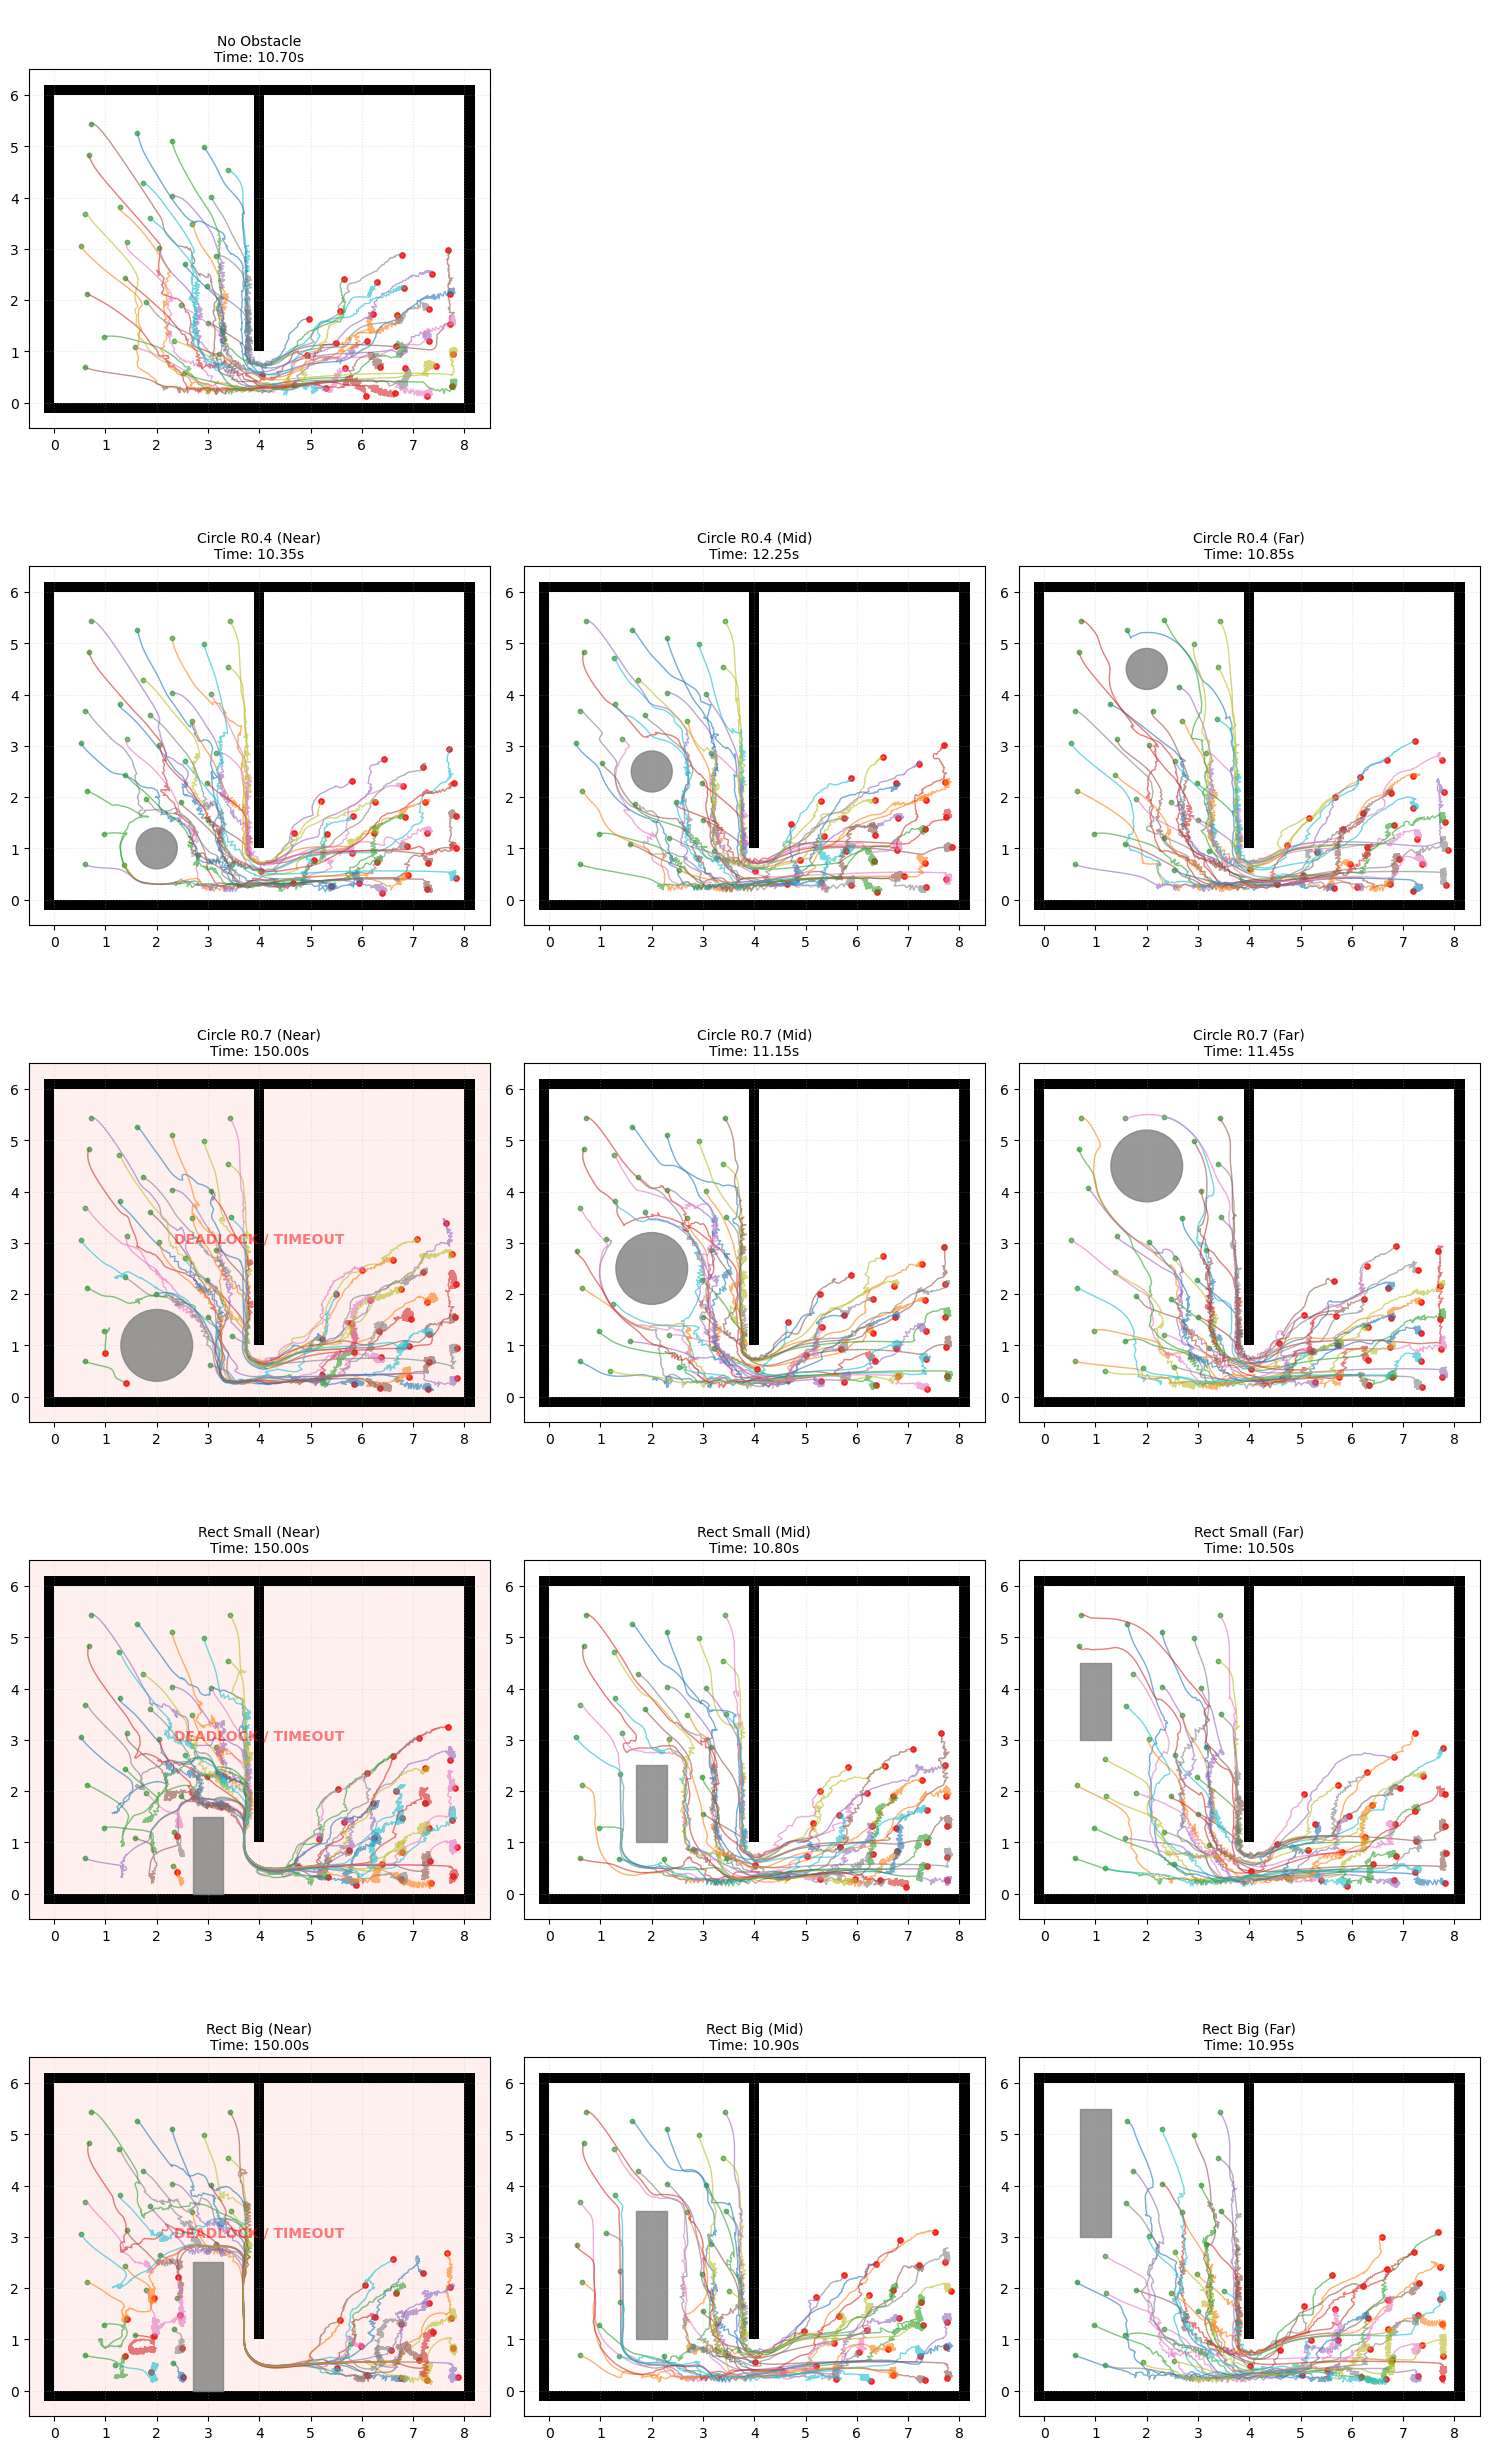

In [18]:
# Visualization
fig, axes = plt.subplots(5, 3, figsize=(15, 25))
grid_mapping = {
    0: (0, 0),                         # Row 0: Baseline
    1: (1, 0), 2: (1, 1), 3: (1, 2),   # Row 1: Small Circles
    4: (2, 0), 5: (2, 1), 6: (2, 2),   # Row 2: Big Circles
    7: (3, 0), 8: (3, 1), 9: (3, 2),   # Row 3: Small Rects
    10: (4, 0), 11: (4, 1), 12: (4, 2) # Row 4: Big Rects
}

# Hide unused axes
axes[0, 1].axis('off'); axes[0, 2].axis('off')

for idx, row in df_results.iterrows():
    if idx not in grid_mapping: continue
    r, c = grid_mapping[idx]
    ax = axes[r, c]
    
    scenario_name = row['Scenario']
    time_val = row['Time']
    trajs = row['History'].transpose(1, 0, 2)
    obs_list = row['Obstacles']
    
    # 1. Setup Domain
    ax.set_xlim(-0.5, 8.5); ax.set_ylim(-0.5, 6.5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.3)
    
    # 2. Draw Static Walls from Geometry Definition
    for w in walls_geom:
        ax.add_patch(patches.Rectangle((w[0], w[1]), w[2], w[3], facecolor='k'))
        
    # 3. Draw Obstacles
    for obs in obs_list:
        if obs['type'] == 'circle':
            ax.add_patch(plt.Circle(obs['center'], obs['radius'], color='gray', alpha=0.8))
        elif obs['type'] == 'rect':
            x_min, x_max = obs['x_range']
            y_min, y_max = obs['y_range']
            ax.add_patch(plt.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, color='gray', alpha=0.8))

    # 4. Draw Trajectories, Red background if timeout
    if time_val >= 150.0:
        ax.set_facecolor('#fff0f0')
        ax.text(4, 3, "DEADLOCK / TIMEOUT", color='red', ha='center', fontweight='bold', alpha=0.5)
    
    for p in trajs:
        ax.plot(p[:, 0], p[:, 1], lw=1, alpha=0.6) # Trajectory line
        ax.scatter(p[0, 0], p[0, 1], c='green', s=10, alpha=0.5) # Start
        ax.scatter(p[-1, 0], p[-1, 1], c='red', s=15, alpha=0.8) # End
        
    ax.set_title(f"{scenario_name}\nTime: {time_val:.2f}s", fontsize=10)

plt.tight_layout()
plt.show()